# How far is a ballot drop box — Washington statewide, Nov 2024

Companion to `ballot_access_snohomish.ipynb`, scaled up. That piece found two disagreeing answers depending on granularity: no relationship at the (population-confounded) precinct level, a moderate but statistically inconclusive one at the (real-rate, n=20) city level within a single county. Going statewide fixes the sample-size problem directly — all 39 WA counties have an official registered-voter turnout rate for this exact election, no aggregation needed. It also surfaced a second, unrelated bug: the "distance to nearest drop box" metric itself was broken for several counties until the reference point was fixed (see below) — a reminder that scaling up a piece can expose problems the smaller version was too clean to catch.

**Same caveat as before:** Washington votes entirely by mail with prepaid return postage. A drop box is a convenience, not the only path to return a ballot. This is a check for a relationship, not a "barrier to voting" story.

In [1]:
import csv
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from scipy import stats

DATA = Path("data")
TURNOUT_CSV = DATA / "wa_county_turnout_2024.csv"
COUNTY_GEOJSON = DATA / "wa_county_boundaries.geojson"
DROPBOX_CSV = DATA / "wa_dropboxes_2026.csv"
BLOCKGROUP_POP_CSV = DATA / "wa_blockgroup_population_2024.csv"


## Load county turnout (official, all 39 counties, one page)

Unlike Snohomish's city-level rate (recovered from an overwritten report via the Wayback Machine), WA's own [results.vote.wa.gov/results/20241105/Turnout.html](https://results.vote.wa.gov/results/20241105/Turnout.html) publishes registered voters, ballots cast, and turnout % for every county on a single live page for this exact election. No archaeology needed here — the harder problem this time is the drop box list (see below).

In [2]:
turnout = {}
with open(TURNOUT_CSV, newline="") as f:
    for row in csv.DictReader(f):
        turnout[row["county"]] = {
            "registered": int(row["registered_voters"]),
            "ballots": int(row["ballots_cast"]),
            "turnout_pct": float(row["turnout_pct"]),
        }

print(f"{len(turnout)} counties loaded")
pcts = np.array([v["turnout_pct"] for v in turnout.values()])
print(f"turnout range: {pcts.min():.1f}% ({[k for k,v in turnout.items() if v['turnout_pct']==pcts.min()][0]}) "
      f"to {pcts.max():.1f}% ({[k for k,v in turnout.items() if v['turnout_pct']==pcts.max()][0]})")


39 counties loaded
turnout range: 65.0% (Adams) to 87.7% (Jefferson)


## Drop box locations — one honest dating caveat

WA Secretary of State publishes a single statewide drop box list (`data/wa_dropboxes_2026_source.xlsx`, fetched from sos.wa.gov — note the direct file URL worked over plain `curl` with a browser user-agent even though the site's WAF blocks both the automated fetch tool and default `curl`). It's dated for the **current** (2026) cycle, not Nov 2024. Drop box locations are close to permanent county infrastructure — auditors don't typically relocate them between cycles — so this is used as a reasonable stand-in, same as the Snohomish piece's own drop-box source. 573 of 630 rows are `Drop Box` type (the rest are `Voting Center`, a different facility, excluded here for consistency with the county-level piece).

In [3]:
dropboxes_by_county = {}
with open(DROPBOX_CSV, newline="") as f:
    for row in csv.DictReader(f):
        dropboxes_by_county.setdefault(row["county"], []).append((float(row["lat"]), float(row["lon"])))

all_lat = np.array([lat for boxes in dropboxes_by_county.values() for lat, lon in boxes])
all_lon = np.array([lon for boxes in dropboxes_by_county.values() for lat, lon in boxes])
print(f"{len(all_lat)} drop boxes across {len(dropboxes_by_county)} counties")
print(f"drop boxes per county: min {min(len(v) for v in dropboxes_by_county.values())}, "
      f"median {int(np.median([len(v) for v in dropboxes_by_county.values()]))}, "
      f"max {max(len(v) for v in dropboxes_by_county.values())}")


572 drop boxes across 39 counties
drop boxes per county: min 1, median 10, max 89


## County reference point: population-weighted, not geometric

First pass used a geometric centroid (mean of county boundary vertices) — same technique as the Snohomish precinct piece. At county scale that turned out to be a real problem, not just a disclaimer-worthy simplification: Jefferson and Whatcom counties both stretch from a populated coastal strip deep into uninhabited Olympic/Cascade wilderness, and King County reaches from Seattle into the Cascade foothills. A geometric centroid for any of these can land in a national park, tens of miles from anywhere anyone actually lives — which would make "distance to nearest drop box" mostly noise for exactly the counties most likely to show a real effect.

Fix: WA's Office of Financial Management publishes small-area population estimates for 2024 down to the census block group (5,311 of them statewide, via the same ArcGIS pattern as the county boundaries). Population-weighted centroid = each block group's own representative point, averaged and weighted by its 2024 population. This is the number actually used below; the geometric version is kept only as a comparison to show the fix mattered.

In [4]:
def exterior_rings(geometry):
    coords = geometry["coordinates"]
    polys = [coords] if geometry["type"] == "Polygon" else coords
    for poly in polys:
        yield np.array(poly[0])


def geometric_centroid_lonlat(geometry):
    all_pts = np.concatenate(list(exterior_rings(geometry)))
    return all_pts[:, 0].mean(), all_pts[:, 1].mean()


def haversine_miles(lon1, lat1, lon2, lat2):
    R = 3958.8
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


pop_points_by_county = {}
with open(BLOCKGROUP_POP_CSV, newline="") as f:
    for row in csv.DictReader(f):
        pop_points_by_county.setdefault(row["county"], []).append(
            (float(row["pop2024"]), float(row["lat"]), float(row["lon"]))
        )

def pop_weighted_centroid_lonlat(county):
    pts = pop_points_by_county[county]
    pop = np.array([p[0] for p in pts])
    lat = np.array([p[1] for p in pts])
    lon = np.array([p[2] for p in pts])
    w = pop / pop.sum()
    return (lon * w).sum(), (lat * w).sum()


print(f"{sum(len(v) for v in pop_points_by_county.values())} block groups across {len(pop_points_by_county)} counties")
print("check — geometric vs. population-weighted centroid, three large mixed-terrain counties:")
geojson = json.loads(COUNTY_GEOJSON.read_text())
geom_by_county = {f["properties"]["JURISDICT_LABEL_NM"]: f["geometry"] for f in geojson["features"]}
for county in ["Jefferson", "Whatcom", "King"]:
    glon, glat = geometric_centroid_lonlat(geom_by_county[county])
    plon, plat = pop_weighted_centroid_lonlat(county)
    shift = haversine_miles(glon, glat, plon, plat)
    print(f"  {county:10s} geometric=({glat:.3f},{glon:.3f})  pop-weighted=({plat:.3f},{plon:.3f})  shifted {shift:.1f} mi")


5311 block groups across 39 counties
check — geometric vs. population-weighted centroid, three large mixed-terrain counties:
  Jefferson  geometric=(47.777,-123.724)  pop-weighted=(48.017,-122.820)  shifted 45.0 mi
  Whatcom    geometric=(48.830,-121.421)  pop-weighted=(48.823,-122.485)  shifted 48.4 mi
  King       geometric=(47.370,-121.398)  pop-weighted=(47.552,-122.231)  shifted 40.9 mi


## Distance from each county's population-weighted center to its nearest drop box

In [5]:
records = []
for county in turnout:
    clon, clat = pop_weighted_centroid_lonlat(county)
    boxes = dropboxes_by_county.get(county, [])
    box_lat = np.array([b[0] for b in boxes])
    box_lon = np.array([b[1] for b in boxes])
    dist = haversine_miles(clon, clat, box_lon, box_lat).min()
    records.append({
        "county": county, "lon": clon, "lat": clat, "dropbox_dist_mi": dist,
        "geometry": geom_by_county[county], **turnout[county],
    })

dists = np.array([r["dropbox_dist_mi"] for r in records])
print(f"{len(records)} counties matched")
print(f"distance to nearest drop box (mi): min {dists.min():.2f}, median {np.median(dists):.2f}, max {dists.max():.2f}")


39 counties matched
distance to nearest drop box (mi): min 0.36, median 2.56, max 10.03


## Map: distance to nearest drop box, by county

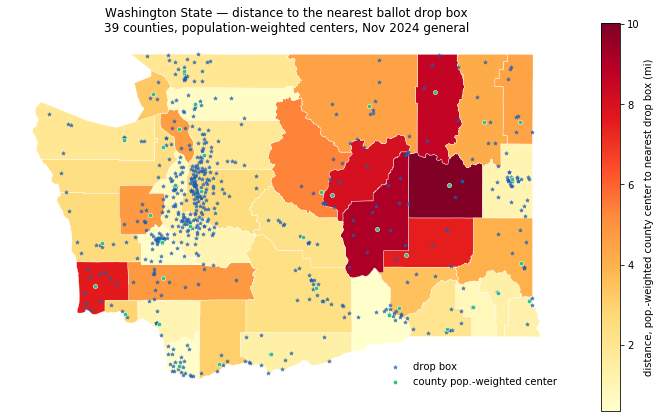

In [6]:
all_lats_plot = np.array([r["lat"] for r in records])
LAT_ASPECT = 1 / np.cos(np.radians(all_lats_plot.mean()))

fig, ax = plt.subplots(figsize=(10, 8))
patches, values = [], []
for r in records:
    for ring in exterior_rings(r["geometry"]):
        patches.append(Polygon(ring, closed=True))
        values.append(r["dropbox_dist_mi"])
coll = PatchCollection(patches, cmap="YlOrRd")
coll.set_array(np.array(values))
coll.set_edgecolor("white")
coll.set_linewidth(0.4)
ax.add_collection(coll)
ax.scatter(all_lon, all_lat, marker="*", s=12, c="#1a5fb4", alpha=0.6, zorder=5, label="drop box")
ax.autoscale_view()
ax.set_aspect(LAT_ASPECT)
ax.axis("off")
ax.scatter([r["lon"] for r in records], [r["lat"] for r in records],
           marker="o", s=18, c="#2ec27e", edgecolor="white", linewidth=0.5, zorder=6,
           label="county pop.-weighted center")
ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.9, edgecolor="none")
cbar = fig.colorbar(coll, ax=ax, shrink=0.7)
cbar.set_label("distance, pop.-weighted county center to nearest drop box (mi)")
ax.set_title(
    "Washington State — distance to the nearest ballot drop box\n"
    "39 counties, population-weighted centers, Nov 2024 general",
    fontsize=12,
)
fig.tight_layout()
fig.savefig("ballot_access_statewide_map.png", dpi=150, bbox_inches="tight")
plt.show()


## Does distance relate to the real turnout rate?

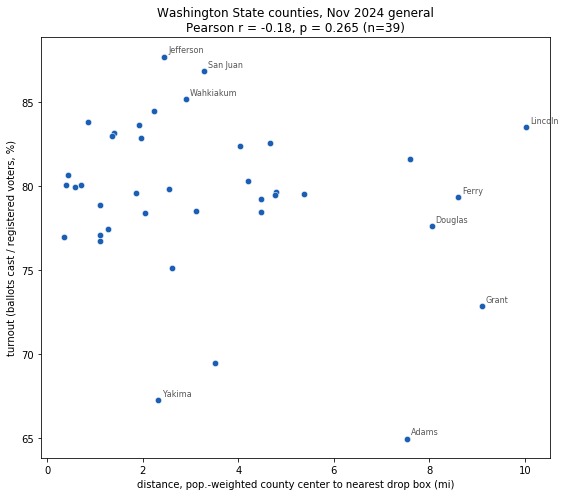

Pearson r (distance vs. turnout, county level): -0.183, p=0.2645, n=39


In [7]:
turnout_arr = np.array([r["turnout_pct"] for r in records])
rho, pval = stats.pearsonr(dists, turnout_arr)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(dists, turnout_arr, s=40, color="#1a5fb4", edgecolor="white", linewidth=0.5)
for r in records:
    if r["dropbox_dist_mi"] > 8 or r["turnout_pct"] > 85 or r["turnout_pct"] < 68:
        ax.annotate(r["county"], (r["dropbox_dist_mi"], r["turnout_pct"]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points", color="#555555")
ax.set_xlabel("distance, pop.-weighted county center to nearest drop box (mi)")
ax.set_ylabel("turnout (ballots cast / registered voters, %)")
ax.set_title(
    f"Washington State counties, Nov 2024 general\nPearson r = {rho:.2f}, p = {pval:.3f} (n={len(records)})",
    fontsize=12,
)
fig.tight_layout()
fig.savefig("ballot_access_statewide_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Pearson r (distance vs. turnout, county level): {rho:.3f}, p={pval:.4f}, n={len(records)}")


In [8]:
# Self-check: guards against a silently broken join or a stale/incomplete source file.
assert len(records) == 39, f"expected all 39 WA counties, got {len(records)}"
assert dists.min() >= 0, "negative distance"
assert dists.max() < 60, f"implausible max centroid distance for a WA county: {dists.max():.1f} mi"
assert turnout_arr.min() > 50 and turnout_arr.max() < 95, f"turnout range looks wrong: {turnout_arr.min():.1f}-{turnout_arr.max():.1f}%"
assert 0 <= pval <= 1, f"invalid p-value: {pval}"
assert sum(len(v) for v in dropboxes_by_county.values()) == len(all_lat), "drop box count mismatch"
assert len(pop_points_by_county) == 39, f"expected block-group population for all 39 counties, got {len(pop_points_by_county)}"
total_pop = sum(p[0] for pts in pop_points_by_county.values() for p in pts)
assert 7_000_000 < total_pop < 9_000_000, f"statewide 2024 population estimate looks wrong: {total_pop:,.0f}"
print("self-checks passed")


self-checks passed


## Source & caption notes

- **Finding (n=39 counties, real turnout rate, population-weighted distance):** Pearson r = -0.18, p = 0.26 — a weak relationship in the expected direction (farther from a drop box, lower turnout), well short of conventional significance at this sample size. Read the exact numbers from the cell above on any re-run rather than trusting this restatement.
- **The centroid fix changed the answer, not just the justification for it.** A first-pass geometric centroid gave r = 0.03, p = 0.84 — indistinguishable from nothing. Once the reference point was corrected to reflect where people actually live, a real (if still statistically inconclusive) signal emerged. Both numbers are reported here on purpose: the geometric-centroid run wasn't a rough draft to discard quietly, it's evidence that the population-weighting mattered.
- **Three findings now, three granularities, none of them proof:** precinct-level raw counts (null, confounded by population size), one county's cities using a real rate (suggestive, n=20, not significant), all 39 counties using a real rate and a corrected distance metric (weak and directionally consistent, still not significant). The honest summary of this whole sub-thread is "probably something small, not confirmed" — not a headline.
- Turnout: [results.vote.wa.gov/results/20241105/Turnout.html](https://results.vote.wa.gov/results/20241105/Turnout.html) — official, final, all 39 counties on one page, no aggregation needed (contrast with the Snohomish piece, where city-level turnout had to be recovered from an overwritten report via the Wayback Machine).
- Drop boxes: WA Secretary of State's statewide list (`data/wa_dropboxes_2026_source.xlsx`), `Drop Box` type only (`Voting Center` rows excluded). Dated for the current (2026) cycle, used as a stand-in for Nov 2024 locations — disclosed, not hidden; WA drop boxes are largely permanent county infrastructure.
- County boundaries: WA Department of Natural Resources GIS ("WA County Boundaries" layer via geo.wa.gov), joined to turnout and drop box data by county name — all 39 matched exactly, no name-normalization needed this time (contrast with the Snohomish precinct piece's messy name-based join).
- County reference point is **population-weighted**, not geometric: WA OFM's 2024 small-area population estimates by census block group (5,311 statewide), weighted-averaged per county. A first-pass geometric centroid (mean of boundary vertices, same technique as the Snohomish piece) put Jefferson and Whatcom counties' reference points dozens of miles into uninhabited wilderness — caught and fixed before trusting the result, not after. The comparison cell above quantifies the shift for the three counties where it mattered most.
- Washington is vote-by-mail with prepaid return postage; a drop box is a convenience, not the only path to return a ballot.